# Celda 1 — Montar Drive e imports


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

BASE_PATH   = '/content/drive/MyDrive/project_factoria/waste_classifier'
UNIFIED     = os.path.join(BASE_PATH, 'datasets/unified')
METADATA    = os.path.join(BASE_PATH, 'datasets/metadata')
CHECKPOINTS = os.path.join(BASE_PATH, 'checkpoints')
OUTPUTS     = os.path.join(BASE_PATH, 'outputs')
os.makedirs(OUTPUTS, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

Mounted at /content/drive
Dispositivo: cuda


# Celda 2 — Cargar configuración y dataset de test


In [2]:
with open(os.path.join(METADATA, 'config.json')) as f:
    config = json.load(f)

IMAGENET_MEAN = config['imagenet_mean']
IMAGENET_STD  = config['imagenet_std']

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

dataset_test = datasets.ImageFolder(
    root=os.path.join(UNIFIED, 'test'),
    transform=transform_test
)
loader_test = DataLoader(dataset_test, batch_size=32, shuffle=False,
                         num_workers=2, pin_memory=True)

CLASSES = dataset_test.classes
print(f"Clases: {CLASSES}")
print(f"Imágenes de test: {len(dataset_test)}")
print(f"Batches: {len(loader_test)}")

Clases: ['carton', 'metal', 'no_reciclable', 'organico', 'papel', 'plastico', 'vidrio']
Imágenes de test: 2276
Batches: 72


# Celda 3 — Cargar el mejor modelo


In [3]:
checkpoint = torch.load(
    os.path.join(CHECKPOINTS, 'best_model_ft.pth'),
    map_location=device
)

model = models.efficientnet_b0(weights=None)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, len(CLASSES))
)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"Modelo cargado — epoch {checkpoint['epoch']}")
print(f"Val acc fine-tuning: {checkpoint['val_acc']*100:.2f}%")

Modelo cargado — epoch 6
Val acc fine-tuning: 90.33%


# Celda 4 — Inferencia completa sobre test set


In [4]:
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for imgs, labels in loader_test:
        imgs   = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc_test = (all_preds == all_labels).mean() * 100
print(f"Accuracy en TEST SET: {acc_test:.2f}%")

Accuracy en TEST SET: 89.06%


# Celda 5 — Reporte de clasificación por clase


In [5]:
print("Reporte de clasificación:\n")
print(classification_report(all_labels, all_preds,
                             target_names=CLASSES, digits=3))

Reporte de clasificación:

               precision    recall  f1-score   support

       carton      0.892     0.897     0.895       175
        metal      0.688     0.954     0.799       196
no_reciclable      0.987     0.890     0.936       989
     organico      0.904     0.973     0.937       183
        papel      0.826     0.888     0.856       214
     plastico      0.819     0.779     0.798       226
       vidrio      0.881     0.884     0.882       293

     accuracy                          0.891      2276
    macro avg      0.856     0.895     0.872      2276
 weighted avg      0.901     0.891     0.893      2276



# Celda 6 — Confusion matrix


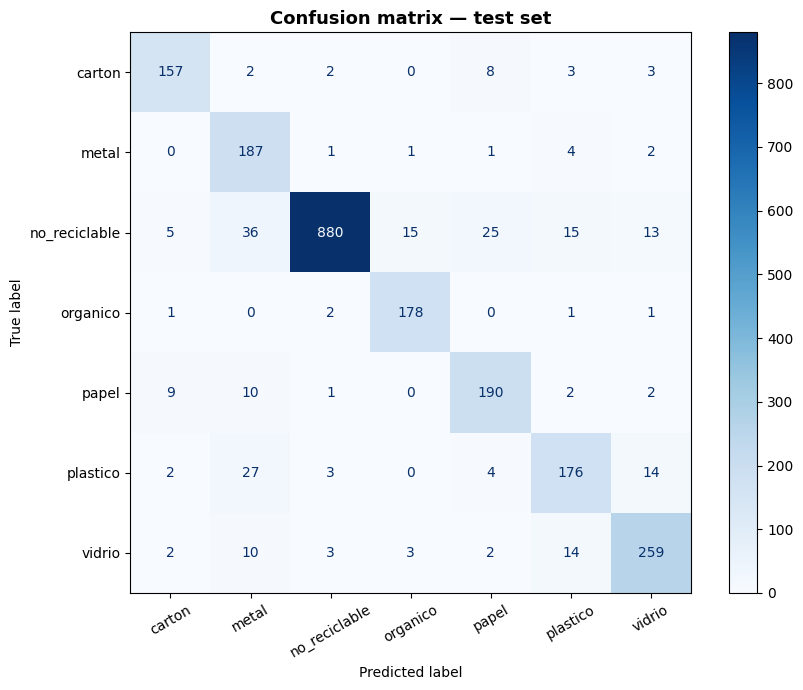

Guardada: confusion_matrix.png


In [6]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title('Confusion matrix — test set', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardada: confusion_matrix.png")

# Celda 7 — F1 por clase (gráfico de barras)


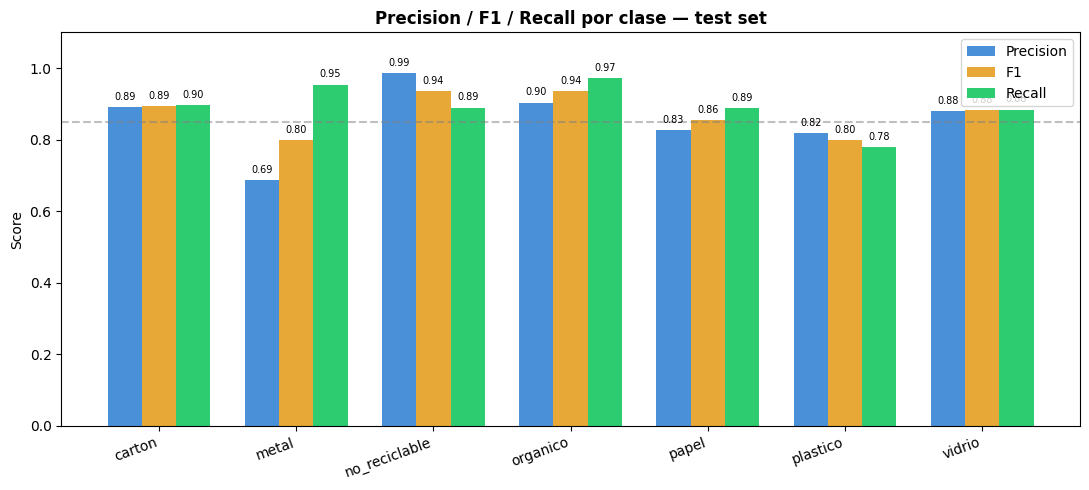

In [7]:
from sklearn.metrics import f1_score, precision_score, recall_score

f1s  = f1_score(all_labels, all_preds, average=None)
prec = precision_score(all_labels, all_preds, average=None)
rec  = recall_score(all_labels, all_preds, average=None)

x = np.arange(len(CLASSES))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, prec, width, label='Precision', color='#4A90D9')
ax.bar(x,         f1s,  width, label='F1',        color='#E8A838')
ax.bar(x + width, rec,  width, label='Recall',    color='#2ECC71')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Precision / F1 / Recall por clase — test set', fontweight='bold')
ax.legend()
ax.axhline(0.85, color='gray', linestyle='--', alpha=0.5, label='85% referencia')
for i, (p, f, r) in enumerate(zip(prec, f1s, rec)):
    ax.text(i - width, p + 0.02, f'{p:.2f}', ha='center', fontsize=7)
    ax.text(i,         f + 0.02, f'{f:.2f}', ha='center', fontsize=7)
    ax.text(i + width, r + 0.02, f'{r:.2f}', ha='center', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'f1_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()

# Celda 8 — Ejemplos peor clasificados por clase


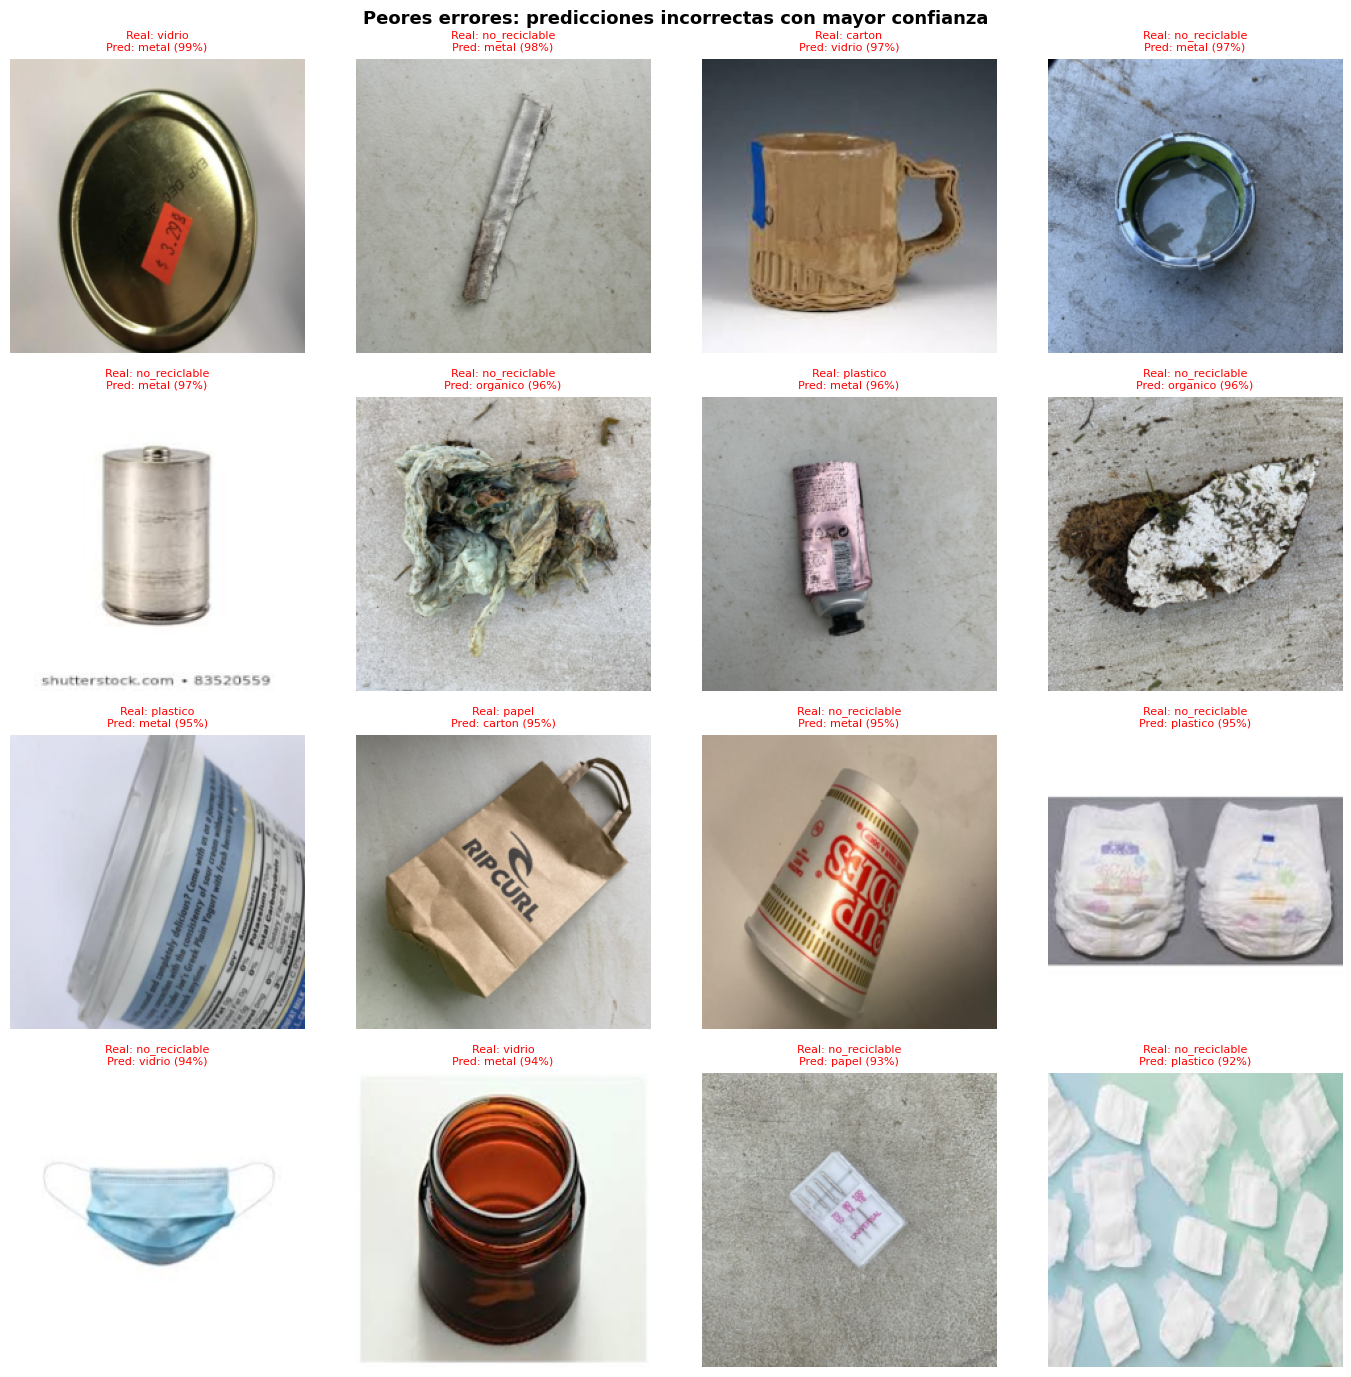

Guardado: worst_errors.png


In [8]:
from PIL import Image

def denormalizar(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Recargar test sin shuffle para acceder a las rutas
dataset_test_raw = datasets.ImageFolder(
    root=os.path.join(UNIFIED, 'test'),
    transform=transform_test
)

# Encontrar los peores ejemplos: predicción incorrecta con mayor confianza
errores = []
for idx in range(len(all_preds)):
    if all_preds[idx] != all_labels[idx]:
        confianza = all_probs[idx][all_preds[idx]]
        errores.append((confianza, idx))

errores.sort(reverse=True)  # los más confiados pero equivocados
top_errores = errores[:16]

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Peores errores: predicciones incorrectas con mayor confianza',
             fontweight='bold', fontsize=13)

for ax, (confianza, idx) in zip(axes.flat, top_errores):
    img_tensor, _ = dataset_test_raw[idx]
    img = denormalizar(img_tensor).permute(1,2,0).numpy()
    ax.imshow(img)
    real = CLASSES[all_labels[idx]]
    pred = CLASSES[all_preds[idx]]
    ax.set_title(f'Real: {real}\nPred: {pred} ({confianza:.0%})',
                fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'worst_errors.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Guardado: worst_errors.png")

# Celda 9 — Resumen final


In [9]:
print("=" * 55)
print("RESUMEN FINAL DEL PROYECTO")
print("=" * 55)
print(f"\nModelo:          EfficientNet-B0 (transfer learning)")
print(f"Parámetros:      4,016,515 total — 8,967 entrenados")
print(f"Epochs:          15")
print(f"Clases:          {len(CLASSES)}")
print(f"Dataset:         22,794 imágenes (3 fuentes combinadas)")
print(f"\nResultados en TEST SET:")
print(f"  Accuracy:      {acc_test:.2f}%")
print(f"\nF1 por clase:")
for c, f in zip(CLASSES, f1s):
    bar = '█' * int(f * 20)
    print(f"  {c:<18} {f:.3f}  {bar}")
print(f"\nArtefactos guardados en outputs/:")
archivos = os.listdir(OUTPUTS)
for a in sorted(archivos):
    print(f"  {a}")
print("=" * 55)

RESUMEN FINAL DEL PROYECTO

Modelo:          EfficientNet-B0 (transfer learning)
Parámetros:      4,016,515 total — 8,967 entrenados
Epochs:          15
Clases:          7
Dataset:         22,794 imágenes (3 fuentes combinadas)

Resultados en TEST SET:
  Accuracy:      89.06%

F1 por clase:
  carton             0.895  █████████████████
  metal              0.799  ███████████████
  no_reciclable      0.936  ██████████████████
  organico           0.937  ██████████████████
  papel              0.856  █████████████████
  plastico           0.798  ███████████████
  vidrio             0.882  █████████████████

Artefactos guardados en outputs/:
  class_distribution.png
  class_imbalance.png
  class_weights.png
  confusion_matrix.png
  f1_per_class.png
  finetuning_curves.png
  resolution_distribution.png
  sample_batch_augmented.png
  samples_per_class.png
  training_curves.png
  worst_errors.png
